In [1]:
# Import thư viện & Cấu hình thiết bị (Bản SIGMOID - 1 Nơ-ron Đầu ra)
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image
from tkinter import Tk
from tkinter.filedialog import askopenfilename

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Đang sử dụng thiết bị:', device)

Đang sử dụng thiết bị: cpu


In [2]:
# Load & Chuẩn hóa dữ liệu Chest X-Ray (Sigmoid - BCE Loss pos_weight)
base_dir = './chest_xray/chest_xray' if os.path.exists('./chest_xray/chest_xray/train') else './chest_xray'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Định nghĩa các phép biến đổi (Transforms) cho ảnh
transform_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dữ liệu bằng ImageFolder (NORMAL=0, PNEUMONIA=1)
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform_train)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform_test)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform_test)

# Tạo DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = train_dataset.classes
class_counts = [train_dataset.targets.count(i) for i in range(len(class_names))]
# Tính pos_weight cho nhãn PNEUMONIA (1) trong BCEWithLogitsLoss
pos_weight = torch.tensor([class_counts[0] / class_counts[1]]).to(device)

print(f"Các lớp nhãn (Classes): {class_names}")
print(f"Số lượng ảnh Train - NORMAL (0): {class_counts[0]}, PNEUMONIA (1): {class_counts[1]}")
print(f"Trọng số pos_weight cho BCE loss: {pos_weight.item():.3f}")
print(f"Số lượng tổng - Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Các lớp nhãn (Classes): ['NORMAL', 'PNEUMONIA']
Số lượng ảnh Train - NORMAL (0): 1341, PNEUMONIA (1): 3875
Trọng số pos_weight cho BCE loss: 0.346
Số lượng tổng - Train: 5216, Val: 16, Test: 624


In [ ]:
# Định nghĩa Mô hình CNN Phân loại Nhị phân dùng SIGMOID (1 Nơ-ron Output)
class ChestXRayBinaryNet(nn.Module):
    def __init__(self):
        super(ChestXRayBinaryNet, self).__init__()
        # Khối Conv 1: Input 3x128x128 -> Output 32x64x64
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Khối Conv 2: Input 32x64x64 -> Output 64x32x32
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Khối Conv 3: Input 64x32x32 -> Output 128x16x16
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
        # Fully Connected Layers: 128 * 16 * 16 = 32768
        self.fc1 = nn.Linear(128 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 1) # CHỈ 1 NƠ-RON OUTPUT CHO SIGMOID

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        
        x = torch.flatten(x, 1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x) # Trả về 1 Logit z duy nhất
        return x

model = ChestXRayBinaryNet().to(device)
# BCEWithLogitsLoss = Sigmoid + Binary Cross Entropy Loss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.0005)

print("Đã khởi tạo mô hình nhị phân SIGMOID thành công!")
print(model)

Đã khởi tạo mô hình nhị phân SIGMOID thành công!
ChestXRayBinaryNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


In [4]:
# Huấn luyện (Train) Mô hình dùng BCEWithLogitsLoss & Sigmoid
epochs = 10
history = {'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}

for epoch in range(epochs):
    # Training Phase
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.float().unsqueeze(1).to(device) # Shape [batch_size, 1]
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        probs = torch.sigmoid(outputs)
        predicted = (probs >= 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_loss = running_loss / total
    train_acc = correct / total

    # Validation Phase
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item() * inputs.size(0)
            probs = torch.sigmoid(outputs)
            predicted = (probs >= 0.5).float()
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total if val_total > 0 else 0.0
    val_acc = val_correct / val_total if val_total > 0 else 0.0

    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1:02d}/{epochs:02d} - loss: {train_loss:.4f} - acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}')

Epoch 01/10 - loss: 0.2285 - acc: 0.8831 - val_loss: 0.6424 - val_acc: 0.7500
Epoch 02/10 - loss: 0.0788 - acc: 0.9396 - val_loss: 0.7010 - val_acc: 0.6250
Epoch 03/10 - loss: 0.0709 - acc: 0.9494 - val_loss: 0.7745 - val_acc: 0.6875
Epoch 04/10 - loss: 0.0606 - acc: 0.9549 - val_loss: 0.6240 - val_acc: 0.7500
Epoch 05/10 - loss: 0.0588 - acc: 0.9567 - val_loss: 0.2560 - val_acc: 0.8125
Epoch 06/10 - loss: 0.0512 - acc: 0.9624 - val_loss: 0.1845 - val_acc: 0.8750
Epoch 07/10 - loss: 0.0498 - acc: 0.9609 - val_loss: 0.6131 - val_acc: 0.8125
Epoch 08/10 - loss: 0.0504 - acc: 0.9624 - val_loss: 0.4409 - val_acc: 0.8125
Epoch 09/10 - loss: 0.0468 - acc: 0.9664 - val_loss: 0.7767 - val_acc: 0.6250
Epoch 10/10 - loss: 0.0394 - acc: 0.9714 - val_loss: 0.7869 - val_acc: 0.6250


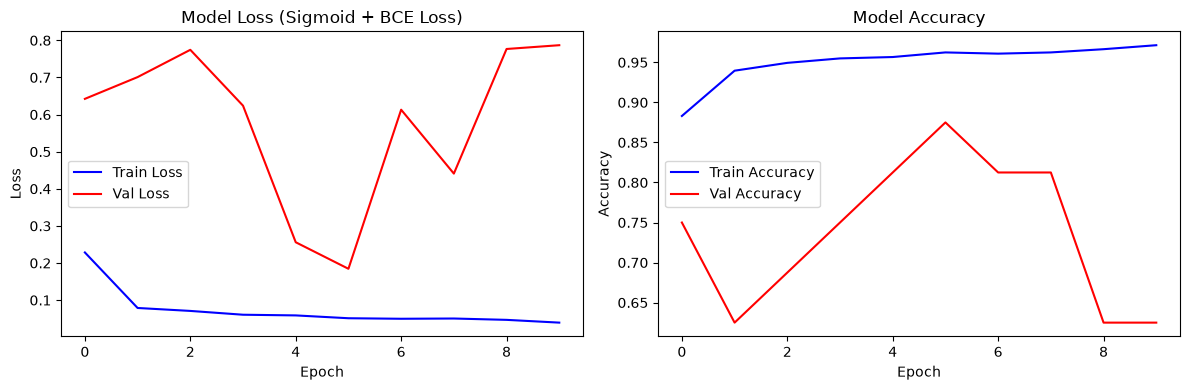

Độ chính xác trên tập Test (Test Accuracy): 74.68%


In [5]:
# Hiển thị Đồ thị Loss & Accuracy và Đánh giá trên tập Test
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Val Loss', color='red')
plt.title('Model Loss (Sigmoid + BCE Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['acc'], label='Train Accuracy', color='blue')
plt.plot(history['val_acc'], label='Val Accuracy', color='red')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Đánh giá độ chính xác trên tập Test
model.eval()
test_correct, test_total = 0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs)
        predicted = (probs >= 0.5).float()
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = test_correct / test_total if test_total > 0 else 0.0
print(f"Độ chính xác trên tập Test (Test Accuracy): {test_acc * 100:.2f}%")

In [1]:
# Chọn ảnh X-quang tùy ý từ máy tính để dự đoán bằng Sigmoid
root = Tk()
root.withdraw()
root.attributes("-topmost", True)

file_path = askopenfilename(
    title="Chọn ảnh X-quang lồng ngực",
    filetypes=[
        ("Ảnh", "*.png *.jpg *.jpeg *.bmp"),
        ("Tất cả file", "*.*")
    ]
)

root.destroy()

if not file_path:
    print("Bạn chưa chọn ảnh!")
else:
    # Mở và tiền xử lý ảnh
    raw_img = Image.open(file_path).convert("RGB")
    
    img_tensor = transform_test(raw_img)
    img_tensor = img_tensor.unsqueeze(0).to(device) # Batch size = 1 -> [1, 3, 128, 128]
    
    # Dự đoán bằng mô hình nhị phân Sigmoid
    model.eval()
    with torch.no_grad():
        output_logit = model(img_tensor)
        prob_pneumonia = torch.sigmoid(output_logit).item() * 100 # Tính xác suất PNEUMONIA (%)
        prob_normal = 100.0 - prob_pneumonia                       # Xác suất NORMAL (%)
        
        result_label = "PNEUMONIA" if prob_pneumonia >= 50.0 else "NORMAL"
        
    print(f"File ảnh: {file_path}")
    print(f"Xác suất [NORMAL: {prob_normal:.2f}%] | [PNEUMONIA: {prob_pneumonia:.2f}%]")
    print(f"==> Kết quả dự đoán nhị phân (Sigmoid): {result_label}")
    
    # Hiển thị ảnh và kết quả dự đoán
    plt.figure(figsize=(6, 6))
    plt.imshow(raw_img)
    title_color = 'green' if result_label == 'NORMAL' else 'red'
    plt.title(f"Dự đoán Sigmoid: {result_label}\n[NORMAL: {prob_normal:.1f}% | PNEUMONIA: {prob_pneumonia:.1f}%]", color=title_color, fontsize=12)
    plt.axis("off")
    plt.show()

NameError: name 'Tk' is not defined